# *SENTIMENT ANALYSIS FOR INDONESIAN POLTICIAL NEWS*
# this notebook using IndoBERT + GRU model

# Import Library + define env & device

In [1]:
print("test")

test


In [2]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Running on: {device}")

2026-05-25 18:30:01.231112: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779733801.424020      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779733801.480278      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779733801.947431      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779733801.947470      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779733801.947472      57 computation_placer.cc:177] computation placer alr

✅ Imports complete. Running on: cuda


# Configuration & Hyperparameter defining

In [3]:
# --- Configuration ---
SEED = 42
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512

# Paths
DATA_PATH = "/kaggle/input/cleaned-indonesian-political-news"
MODEL_PATH = "/kaggle/working"

# Sentiment Model Hyperparameters
GRU_HIDDEN = 256
GRU_LAYERS = 2
DROPOUT = 0.2


set_seed(SEED)

print(f"Model: IndoBERT + GRU ({GRU_LAYERS} layers, {GRU_HIDDEN} hidden)")
print(f"Max Length: {MAX_LENGTH}")

Model: IndoBERT + GRU (2 layers, 256 hidden)
Max Length: 512


# Data loading & integration

In [4]:
# Load Data
df1 = pd.read_csv("/kaggle/input/datasets/davinraffilio9/datalabeled/data_labeled/cnbc_labeled.csv")
df2 = pd.read_csv("/kaggle/input/datasets/davinraffilio9/datalabeled/data_labeled/detik_labeled.csv")
df3 = pd.read_csv("/kaggle/input/datasets/davinraffilio9/datalabeled/data_labeled/kompas_labeled.csv")

print(f"Detik: {len(df1)} | CNBC: {len(df2)} | Kompas: {len(df3)}")

# Combine Datasets
required_cols = ["date", "title", "content", "article_id", "text", "label"]

def _select_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df[required_cols].copy()

df_seed = pd.concat(
    [_select_cols(df1), _select_cols(df2), _select_cols(df3)],
    ignore_index=True
)

print(f"Total Combined Samples: {len(df_seed)}")

Detik: 5343 | CNBC: 9999 | Kompas: 9980
Total Combined Samples: 25322


# EDA & data preprocessing

DATASET DISTRIBUTION (ORIGINAL)
Label Counts:
label
Neutral     14358
Positive     6172
Negative     4792
Name: count, dtype: int64


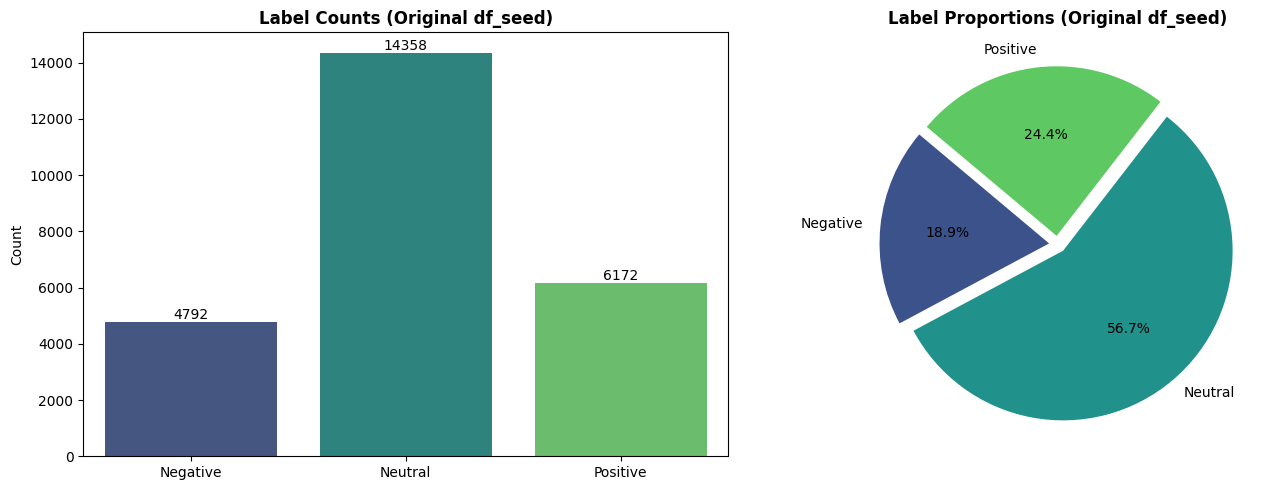


SPLITTING DATASET


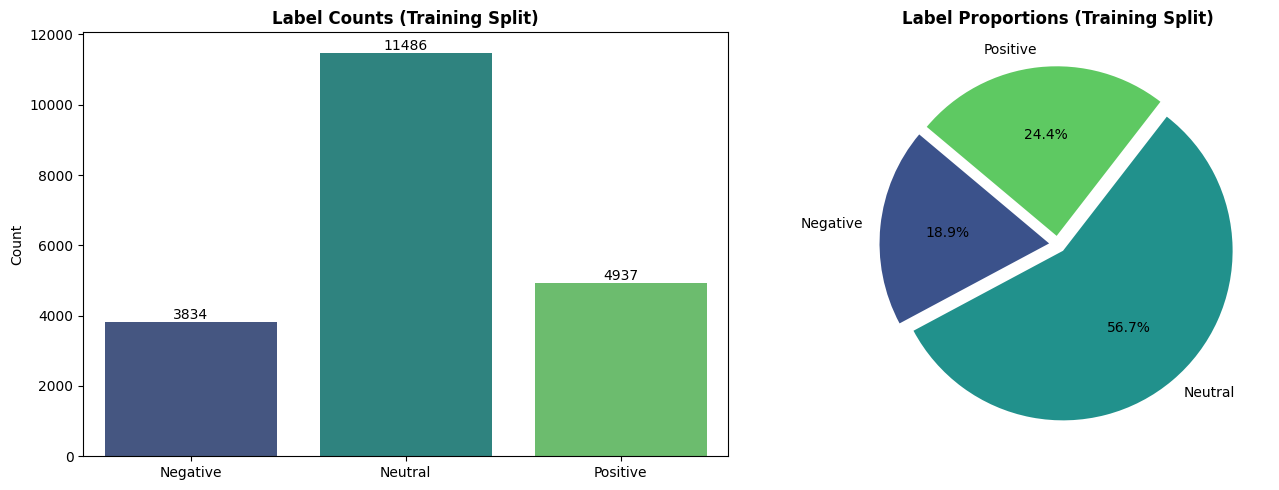


TRAINING CONFIGURATION
Train Size : 20257 samples
Val Size   : 5065 samples
------------------------------
Computed Class Weights (for Loss Function):
  Negative  : 2.6418
  Neutral   : 0.5879
  Positive  : 2.0515


In [5]:

# --- 0. Setup Visualization Function ---
def plot_label_distribution(df, target_col='label', title_suffix=''):
    """
    Creates a bar plot and pie chart for label distribution.
    Auto-detects if labels are original (-1,0,1) or mapped (0,1,2).
    """
    viz_df = df.copy()
    
    # Auto-detect label format
    unique_labels = set(viz_df[target_col].unique())
    if unique_labels.issubset({0, 1, 2}):
        label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} # Mapped ID
    else:
        label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'} # Original Label
        
    viz_df['label_name'] = viz_df[target_col].map(label_map)
    order = ['Negative', 'Neutral', 'Positive']
    
    # Setup plot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Bar Chart (Frequency)
    sns.countplot(x='label_name', data=viz_df, order=order, palette='viridis', ax=ax1)
    ax1.set_title(f'Label Counts {title_suffix}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    
    # Add numbers on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black')

    # 2. Pie Chart (Proportion)
    counts = viz_df['label_name'].value_counts().reindex(order)
    ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette('viridis', 3), explode=(0.05, 0.05, 0.05))
    ax2.set_title(f'Label Proportions {title_suffix}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# --- 1. Check & Visualize Distribution (Original Data) ---
print("="*50)
print("DATASET DISTRIBUTION (ORIGINAL)")
print("="*50)

# Text Output
print("Label Counts:")
print(df_seed['label'].map({-1:'Negative', 0:'Neutral', 1:'Positive'}).value_counts())

# Diagram Output
plot_label_distribution(df_seed, target_col='label', title_suffix='(Original df_seed)')


# --- 2. Train/Val Split ---
print("\n" + "="*50)
print("SPLITTING DATASET")
print("="*50)

train_df, val_df = train_test_split(
    df_seed,
    test_size=0.2,
    stratify=df_seed['label'],
    random_state=SEED
)

# Visualize Train Split to confirm Stratification
plot_label_distribution(train_df, target_col='label', title_suffix='(Training Split)')


# --- 3. Remap Labels (-1, 0, 1 -> 0, 1, 2) ---
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "negative", 1: "neutral", 2: "positive"}

train_df['label_id'] = train_df['label'].map(label_to_id)
val_df['label_id'] = val_df['label'].map(label_to_id)


# --- 4. Compute Class Weights ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)

# Amplify minority class weights (Custom Adjustment)
# Logic: Give more focus to Negative/Positive, less to Neutral
class_weights = class_weights * np.array([1.5, 1.0, 1.5])
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Train Size : {len(train_df)} samples")
print(f"Val Size   : {len(val_df)} samples")
print("-" * 30)
print("Computed Class Weights (for Loss Function):")
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    print(f"  {label:<10}: {class_weights[i]:.4f}")

# Tokenization & dataset prep

In [6]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False, # Padding handled by collator later
            return_tensors=None
        )
        
        return {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels': label
        }

# Create Dataset Objects
train_dataset = SentimentDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['text'].tolist(), val_df['label_id'].tolist(), tokenizer, MAX_LENGTH)

print("✅ Dataset and Tokenizer ready.")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Dataset and Tokenizer ready.


# Model architecture definition (BiLSTM)

In [7]:
class IndoBertGRU(nn.Module):
    def __init__(self, model_name, num_labels=3, gru_hidden=256, gru_layers=2, dropout=0.2, id_to_label=None, label_to_id=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.config.num_labels = num_labels
        
        if id_to_label:
            self.config.id2label = id_to_label
            self.config.label2id = label_to_id

        # GRU instead of LSTM
        # Key differences:
        # - No cell state (c_n) → only hidden state (h_n)
        # - Generally faster training
        # - Fewer parameters than LSTM
        self.gru = nn.GRU(
            input_size=self.config.hidden_size,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,       # BiGRU
            dropout=dropout if gru_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gru_hidden * 2, num_labels)  # *2 for bidirectional
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state

        # Pack sequence for GRU
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        
        # GRU returns (packed_out, h_n) - NO cell state unlike LSTM!
        packed_out, h_n = self.gru(packed)

        # Concat forward and backward hidden states (last layer)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        h = self.dropout(h)
        logits = self.classifier(h)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# Customize trainer & metrics

In [8]:
class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        
        return (focal_loss, outputs) if return_outputs else focal_loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    f1_per_class = f1_score(labels, preds, average=None)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
    }

# Training initialization

In [9]:
# 1. Initialize Model
sentiment_model = IndoBertGRU(
    model_name=MODEL_NAME,
    gru_hidden=GRU_HIDDEN,
    gru_layers=GRU_LAYERS,
    dropout=DROPOUT,
    id_to_label=id_to_label,
    label_to_id=label_to_id
).to(device)

# 2. Training Arguments
training_args = TrainingArguments(
    output_dir=f"{MODEL_PATH}/sentiment_training",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    learning_rate=3e-5,
    num_train_epochs=15,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_dir=f"{MODEL_PATH}/logs",
    logging_steps=50,
    report_to="none",
    fp16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

# 3. Initialize Trainer
trainer = FocalLossTrainer(
    class_weights=class_weights_tensor,
    focal_gamma=2.0,
    model=sentiment_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer Initialized.")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

✅ Trainer Initialized.


# Execute training

In [10]:
print("="*40)
print("🚀 STARTING TRAINING")
print("="*40)

trainer.train()

print("✅ Training Complete.")

🚀 STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Negative,F1 Neutral,F1 Positive
1,1.273800,0.311742,0.578085,0.585883,0.549025,0.602151,0.474594,0.680905
2,1.020200,0.247723,0.611254,0.618659,0.582700,0.640496,0.511094,0.704387
3,0.731300,0.208329,0.694176,0.700726,0.684538,0.713786,0.652847,0.735545
4,0.434500,0.232721,0.716881,0.726703,0.712187,0.778565,0.690565,0.710977
5,0.304100,0.286637,0.739585,0.743513,0.736559,0.754349,0.723830,0.752359
6,0.180300,0.447860,0.818559,0.810354,0.819294,0.790407,0.834640,0.806014
7,0.173300,0.610600,0.809872,0.799598,0.811208,0.768531,0.830263,0.800000
8,0.073600,0.700803,0.811846,0.805046,0.812851,0.795383,0.827561,0.792194
9,0.101500,0.832343,0.831392,0.821135,0.831946,0.795240,0.850204,0.817961
10,0.018800,0.837401,0.818559,0.811086,0.819404,0.793173,0.833790,0.806294


✅ Training Complete.


# Final evaluation

In [11]:
print("Running Final Evaluation...")

# Predict
pred = trainer.predict(val_dataset)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# Metrics
final_metrics = trainer.evaluate()

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Accuracy    : {final_metrics['eval_accuracy']:.4f}")
print(f"Macro F1    : {final_metrics['eval_macro_f1']:.4f}")
print(f"Weighted F1 : {final_metrics['eval_weighted_f1']:.4f}")
print("-" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"], digits=4))

Running Final Evaluation...



FINAL RESULTS
Accuracy    : 0.8351
Macro F1    : 0.8245
Weighted F1 : 0.8354
--------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

    negative     0.7963    0.8079    0.8021       958
     neutral     0.8648    0.8444    0.8545      2872
    positive     0.7998    0.8348    0.8170      1235

    accuracy                         0.8351      5065
   macro avg     0.8203    0.8290    0.8245      5065
weighted avg     0.8360    0.8351    0.8354      5065



# analysis evaluation

In [12]:
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 4.8 MB/s eta 0:00:00a 0:00:01


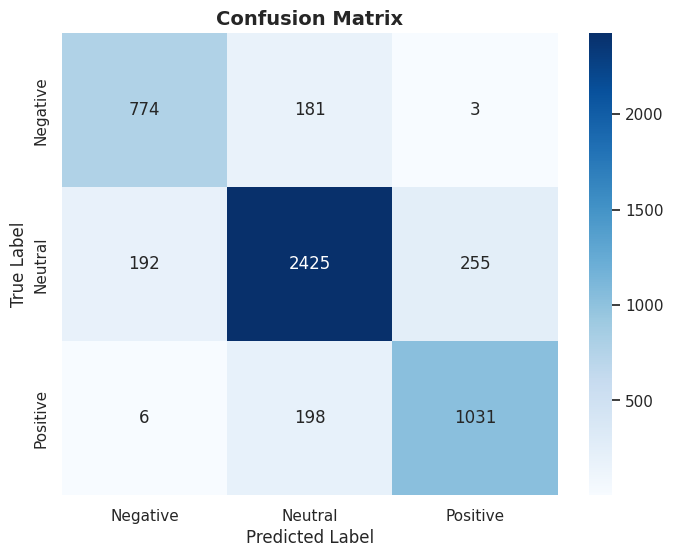

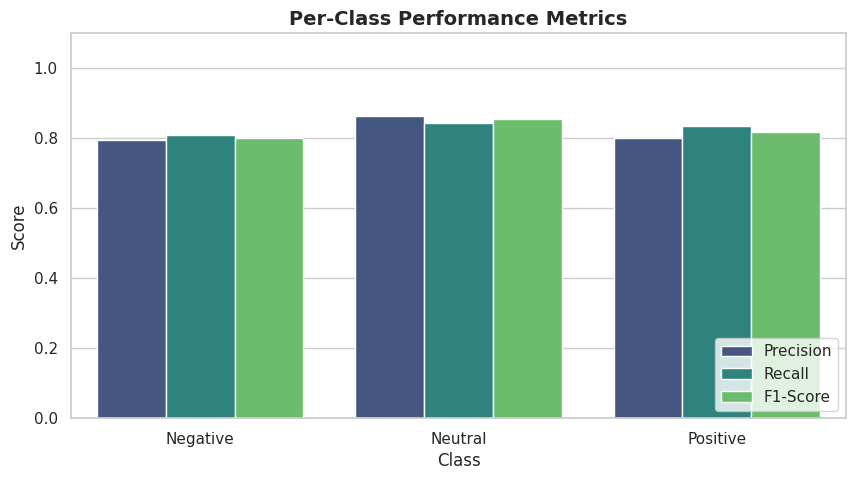


MOST FREQUENT WORDS BY SENTIMENT


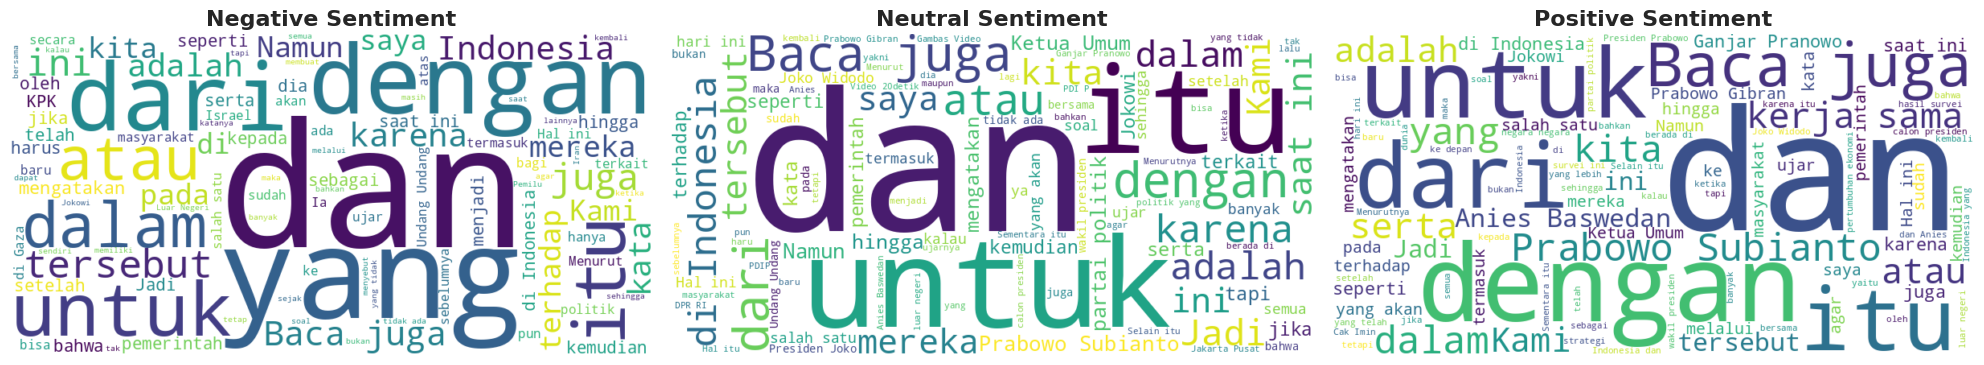


MOST FREQUENT WORDS BY SENTIMENT (CLEANED)


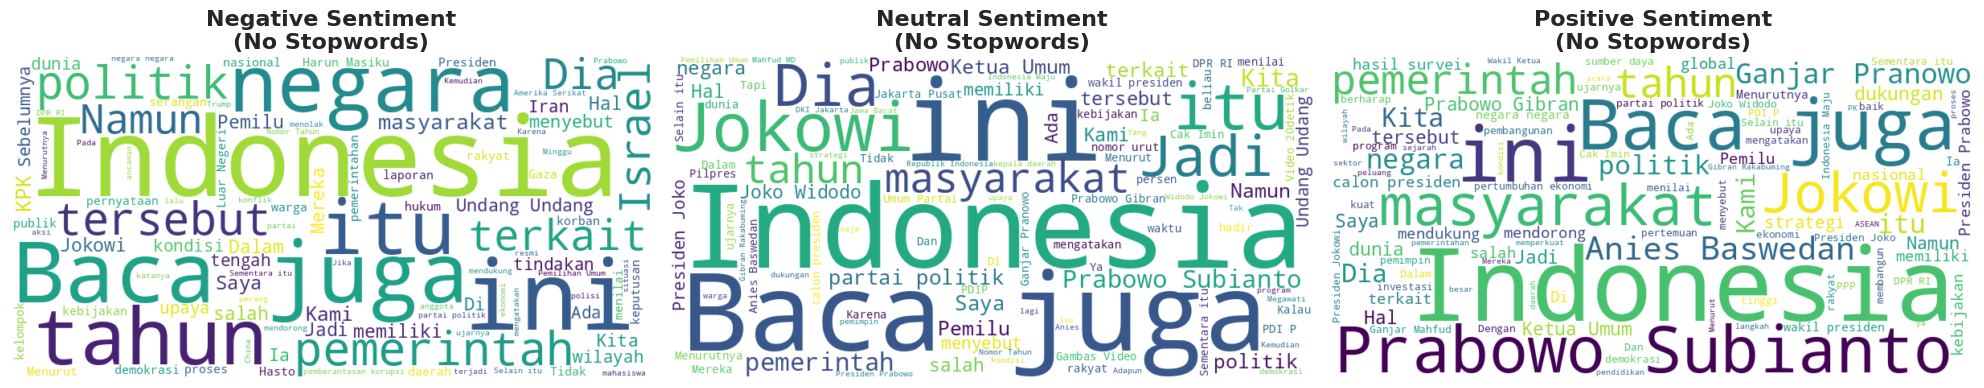

In [13]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# Pastikan style plot rapi
sns.set(style="whitegrid")

def plot_evaluation_results(y_true, y_pred, df_val):
    """
    Menampilkan Confusion Matrix, Grafik Metrik, dan Word Cloud.
    """
    target_names = ["Negative", "Neutral", "Positive"]
    
    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

    # --- 2. Per-Class Metrics Visualization (Precision, Recall, F1) ---
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    metrics_df = pd.DataFrame({
        'Class': target_names * 3,
        'Score': np.concatenate([precision, recall, f1]),
        'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3
    })
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette='viridis')
    plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.show()

    # --- 3. Word Clouds per Sentiment ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT")
    print("="*50)
    
    # Mapping label ID ke nama untuk filtering
    # Pastikan 'val_df' memiliki kolom 'text' dan 'label_id'
    # Kita menggunakan data validasi (df_val)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i
        # Menggunakan kolom 'text' dari val_df
        subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if not subset_text:
            subset_text = "No Data" # Handle jika kosong
            
        wc = WordCloud(width=800, height=400, background_color='white', 
                       colormap='viridis', max_words=100).generate(subset_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    # --- 3. Word Clouds per Sentiment (With Sastrawi Stopword Removal) ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT (CLEANED)")
    print("="*50)
    
    # 1. Inisialisasi Sastrawi StopWord Remover
    factory = StopWordRemoverFactory()
    stopword_remover = factory.create_stop_word_remover()
    
    # Mapping target_names jika belum didefinisikan di luar fungsi
    target_names = ["Negative", "Neutral", "Positive"]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i (0, 1, 2)
        # Menggunakan kolom 'text' dari df_val sesuai struktur dataset kita
        raw_subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if raw_subset_text:
            # 2. Terapkan Stopword Removal dari Sastrawi
            # Proses ini akan menghilangkan kata umum bahasa Indonesia
            cleaned_text = stopword_remover.remove(raw_subset_text)
        else:
            cleaned_text = "No Data"
            
        # 3. Generate WordCloud dari teks yang sudah bersih
        wc = WordCloud(
            width=800, 
            height=400, 
            background_color='white', 
            colormap='viridis', 
            max_words=100
        ).generate(cleaned_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment\n(No Stopwords)', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI VISUALISASI ---
# Pastikan val_df tersedia dari cell sebelumnya
plot_evaluation_results(y_true, y_pred, val_df)

# ABLATION STUDY 1 — GRU Hidden Size Variants
## Reviewer Comment: Justify architectural hyperparameter choices
**Reference:** Cho et al. (2014), "Learning Phrase Representations using RNN Encoder-Decoder", EMNLP.

In [ ]:
print("="*70)
print("ABLATION STUDY 1 — GRU HIDDEN SIZE VARIANTS")
print("Ref: Cho et al. (2014), EMNLP")
print("="*70)

hidden_variants = [128, 256, 384]  # 256 = paper setting
ablation1_results = {}

for hidden_size in hidden_variants:
    marker = " ← PAPER SETTING" if hidden_size == 256 else ""
    print(f"\n--- Testing GRU Hidden Size: {hidden_size}{marker} ---")
    set_seed(SEED)

    model_abl1 = IndoBertGRU(
        model_name=MODEL_NAME,
        gru_hidden=hidden_size,
        gru_layers=GRU_LAYERS,
        dropout=DROPOUT,
        id_to_label=id_to_label,
        label_to_id=label_to_id
    ).to(device)

    abl1_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl1_hidden{hidden_size}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=3e-5,
        num_train_epochs=5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        fp16=True,
        report_to="none",
        seed=SEED,
    )

    abl1_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor,
        focal_gamma=2.0,
        model=model_abl1,
        args=abl1_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    abl1_trainer.train()
    pred_abl1 = abl1_trainer.predict(val_dataset)
    y_pred_abl1 = np.argmax(pred_abl1.predictions, axis=1)
    f1_per = f1_score(y_true, y_pred_abl1, average=None)

    ablation1_results[hidden_size] = {
        'macro_f1': f1_score(y_true, y_pred_abl1, average='macro'),
        'accuracy': accuracy_score(y_true, y_pred_abl1),
        'weighted_f1': f1_score(y_true, y_pred_abl1, average='weighted'),
        'f1_neg': f1_per[0], 'f1_neu': f1_per[1], 'f1_pos': f1_per[2],
    }
    print(f"  Macro F1={ablation1_results[hidden_size]['macro_f1']:.4f}{marker}")

    del model_abl1, abl1_trainer
    torch.cuda.empty_cache()

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sizes = list(ablation1_results.keys())
x_labels = [f'h={s}\n(Paper)' if s == 256 else f'h={s}' for s in sizes]
colors = ['#FF5722' if s == 256 else '#2196F3' for s in sizes]

macro_f1s = [ablation1_results[s]['macro_f1'] for s in sizes]
axes[0].bar(x_labels, macro_f1s, color=colors)
for i, v in enumerate(macro_f1s):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[0].set_ylabel('Macro F1-Score')
axes[0].set_title('Macro F1 per Hidden Size', fontweight='bold')
axes[0].set_ylim(0, 1.05)

f1_pos = [ablation1_results[s]['f1_pos'] for s in sizes]
f1_neg = [ablation1_results[s]['f1_neg'] for s in sizes]
x = np.arange(len(sizes))
w = 0.35
axes[1].bar(x - w/2, f1_neg, w, label='F1-Negative', color='#E53935')
axes[1].bar(x + w/2, f1_pos, w, label='F1-Positive', color='#43A047')
axes[1].set_xticks(x); axes[1].set_xticklabels(x_labels)
axes[1].set_title('Minority Class F1 per Hidden Size', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend()

fig.suptitle('Ablation Study 1: GRU Hidden Size Variants (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation1_hidden_size.png", dpi=150)
plt.show()

print("\nSummary:")
for h, r in ablation1_results.items():
    m = " ← PAPER SETTING" if h == 256 else ""
    print(f"  hidden={h}: Macro F1={r['macro_f1']:.4f}, Acc={r['accuracy']:.4f}{m}")

# ABLATION STUDY 2 — Unidirectional vs Bidirectional GRU
## Reviewer Comment: Justify use of bidirectional architecture
**Reference:** Schuster & Paliwal (1997), "Bidirectional Recurrent Neural Networks", IEEE Trans Signal Processing.

In [ ]:
print("="*70)
print("ABLATION STUDY 2 — UNIDIRECTIONAL vs BIDIRECTIONAL GRU")
print("Ref: Schuster & Paliwal (1997), IEEE Trans Signal Processing")
print("="*70)

class IndoBertGRUVariant(nn.Module):
    def __init__(self, model_name, num_labels=3, gru_hidden=256, gru_layers=2,
                 dropout=0.2, bidirectional=True, id_to_label=None, label_to_id=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.config.num_labels = num_labels
        self.bidirectional = bidirectional
        if id_to_label:
            self.config.id2label = id_to_label
            self.config.label2id = label_to_id
        self.gru = nn.GRU(
            input_size=self.config.hidden_size,
            hidden_size=gru_hidden, num_layers=gru_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if gru_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = gru_hidden * 2 if bidirectional else gru_hidden
        self.classifier = nn.Linear(out_dim, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, h_n = self.gru(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1) if self.bidirectional else h_n[-1]
        h = self.dropout(h)
        logits = self.classifier(h)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits)

ablation2_results = {}
variants_abl2 = [
    ('Unidirectional GRU', False),
    ('Bidirectional GRU (Paper)', True),
]

for name, is_bidir in variants_abl2:
    print(f"\n--- Testing: {name} ---")
    set_seed(SEED)
    model_abl2 = IndoBertGRUVariant(
        model_name=MODEL_NAME, gru_hidden=GRU_HIDDEN, gru_layers=GRU_LAYERS,
        dropout=DROPOUT, bidirectional=is_bidir,
        id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    abl2_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl2_{'bi' if is_bidir else 'uni'}gru",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=4, per_device_eval_batch_size=4,
        gradient_accumulation_steps=4, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    abl2_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=2.0,
        model=model_abl2, args=abl2_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    abl2_trainer.train()
    pred_abl2 = abl2_trainer.predict(val_dataset)
    y_pred_abl2 = np.argmax(pred_abl2.predictions, axis=1)
    params = sum(p.numel() for p in model_abl2.parameters())

    ablation2_results[name] = {
        'macro_f1': f1_score(y_true, y_pred_abl2, average='macro'),
        'accuracy': accuracy_score(y_true, y_pred_abl2),
        'params': params,
    }
    print(f"  Macro F1={ablation2_results[name]['macro_f1']:.4f}, Params={params:,}")
    del model_abl2, abl2_trainer
    torch.cuda.empty_cache()

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names_abl2 = list(ablation2_results.keys())
short = ['Unidirectional', 'Bidirectional\n(Paper)']
colors_abl2 = ['#2196F3', '#FF5722']

axes[0].bar(short, [ablation2_results[n]['macro_f1'] for n in names_abl2], color=colors_abl2)
for i, v in enumerate([ablation2_results[n]['macro_f1'] for n in names_abl2]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[0].set_title('Macro F1-Score', fontweight='bold'); axes[0].set_ylim(0, 1.05)

axes[1].bar(short, [ablation2_results[n]['params']/1e6 for n in names_abl2], color=colors_abl2)
for i, v in enumerate([ablation2_results[n]['params']/1e6 for n in names_abl2]):
    axes[1].text(i, v + 0.1, f'{v:.1f}M', ha='center', fontsize=11)
axes[1].set_title('Total Parameters (Millions)', fontweight='bold')

fig.suptitle('Ablation Study 2: Uni vs Bidirectional GRU (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation2_directionality.png", dpi=150)
plt.show()

for n, r in ablation2_results.items():
    print(f"  {n}: Macro F1={r['macro_f1']:.4f}, Params={r['params']:,}")

# ABLATION STUDY 3 — Focal Loss Gamma Variants
## Reviewer Comment: Justify Focal Loss hyperparameter gamma=2.0
**Reference:** Lin et al. (2020), "Focal Loss for Dense Object Detection", IEEE TPAMI 42(2):318-327.

In [ ]:
print("="*70)
print("ABLATION STUDY 3 — FOCAL LOSS GAMMA VARIANTS")
print("Ref: Lin et al. (2020), IEEE TPAMI 42(2):318-327")
print("="*70)

gamma_variants = [0.0, 1.0, 2.0, 3.0]  # 2.0 = paper; 0.0 = standard CrossEntropy
ablation3_results = {}

for gamma in gamma_variants:
    lbl = "CrossEntropy" if gamma == 0.0 else f"Focal(gamma={gamma})"
    marker = " ← PAPER SETTING" if gamma == 2.0 else ""
    print(f"\n--- {lbl}{marker} ---")
    set_seed(SEED)

    model_abl3 = IndoBertGRU(
        model_name=MODEL_NAME, gru_hidden=GRU_HIDDEN, gru_layers=GRU_LAYERS,
        dropout=DROPOUT, id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    abl3_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/abl3_gamma{gamma}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=4, per_device_eval_batch_size=4,
        gradient_accumulation_steps=4, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    abl3_trainer = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=gamma,
        model=model_abl3, args=abl3_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    abl3_trainer.train()
    pred_abl3 = abl3_trainer.predict(val_dataset)
    y_pred_abl3 = np.argmax(pred_abl3.predictions, axis=1)
    f1_per = f1_score(y_true, y_pred_abl3, average=None)

    ablation3_results[gamma] = {
        'macro_f1': f1_score(y_true, y_pred_abl3, average='macro'),
        'accuracy': accuracy_score(y_true, y_pred_abl3),
        'f1_neg': f1_per[0], 'f1_neu': f1_per[1], 'f1_pos': f1_per[2],
    }
    print(f"  Macro F1={ablation3_results[gamma]['macro_f1']:.4f}{marker}")
    del model_abl3, abl3_trainer
    torch.cuda.empty_cache()

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gammas = list(ablation3_results.keys())
x_labels_g = ['CE\n(γ=0)', 'γ=1.0', 'γ=2.0\n(Paper)', 'γ=3.0']
colors_g = ['#FF5722' if g == 2.0 else '#2196F3' for g in gammas]

axes[0].bar(x_labels_g, [ablation3_results[g]['macro_f1'] for g in gammas], color=colors_g)
for i, v in enumerate([ablation3_results[g]['macro_f1'] for g in gammas]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)
axes[0].set_title('Overall Macro F1', fontweight='bold'); axes[0].set_ylim(0, 1.05)

x_g = np.arange(len(gammas)); w_g = 0.35
axes[1].bar(x_g - w_g/2, [ablation3_results[g]['f1_neg'] for g in gammas], w_g, label='F1-Negative', color='#E53935')
axes[1].bar(x_g + w_g/2, [ablation3_results[g]['f1_pos'] for g in gammas], w_g, label='F1-Positive', color='#43A047')
axes[1].set_xticks(x_g); axes[1].set_xticklabels(x_labels_g)
axes[1].set_title('Minority Class F1 (Neg & Pos)', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend()

fig.suptitle('Ablation Study 3: Focal Loss Gamma Variants (Orange = Paper Setting)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ablation3_focal_gamma.png", dpi=150)
plt.show()

print("\nSummary:")
for g, r in ablation3_results.items():
    lbl = "CrossEntropy" if g == 0.0 else f"Focal(γ={g})"
    marker = " ← PAPER SETTING" if g == 2.0 else ""
    print(f"  {lbl}: Macro F1={r['macro_f1']:.4f}, F1-Neg={r['f1_neg']:.4f}, F1-Pos={r['f1_pos']:.4f}{marker}")

# STRATIFIED 5-FOLD CROSS-VALIDATION
## Reviewer Comment: Single train/val split is insufficient for generalization claims
**Reference:** Kohavi (1995), "A Study of Cross-Validation and Bootstrap for Accuracy Estimation", IJCAI-95.

In [ ]:
from sklearn.model_selection import StratifiedKFold

print("="*70)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("Ref: Kohavi (1995), IJCAI-95")
print("="*70)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

all_texts_kf = df_seed['text'].values
all_labels_kf = df_seed['label'].map(label_to_id).values

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_texts_kf, all_labels_kf)):
    print(f"\n{'='*40}\nFOLD {fold+1}/{N_FOLDS}\n{'='*40}")

    fold_train_texts = all_texts_kf[train_idx].tolist()
    fold_train_labels = all_labels_kf[train_idx].tolist()
    fold_val_texts   = all_texts_kf[val_idx].tolist()
    fold_val_labels  = all_labels_kf[val_idx].tolist()

    fold_cw = compute_class_weight('balanced', classes=np.unique(fold_train_labels), y=fold_train_labels)
    fold_cw = fold_cw * np.array([1.5, 1.0, 1.5])
    fold_cw_tensor = torch.FloatTensor(fold_cw).to(device)

    fold_train_ds = SentimentDataset(fold_train_texts, fold_train_labels, tokenizer, MAX_LENGTH)
    fold_val_ds   = SentimentDataset(fold_val_texts,   fold_val_labels,   tokenizer, MAX_LENGTH)

    set_seed(SEED)
    fold_model = IndoBertGRU(
        model_name=MODEL_NAME, gru_hidden=GRU_HIDDEN, gru_layers=GRU_LAYERS,
        dropout=DROPOUT, id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    fold_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/kfold_fold{fold+1}",
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="macro_f1",
        save_total_limit=1, learning_rate=3e-5, num_train_epochs=15,
        per_device_train_batch_size=4, per_device_eval_batch_size=4,
        gradient_accumulation_steps=4, weight_decay=0.01,
        lr_scheduler_type="cosine", warmup_ratio=0.1,
        fp16=True, report_to="none", seed=SEED,
    )

    fold_trainer = FocalLossTrainer(
        class_weights=fold_cw_tensor, focal_gamma=2.0,
        model=fold_model, args=fold_args,
        train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    fold_trainer.train()

    fold_pred = fold_trainer.predict(fold_val_ds)
    fold_yt = fold_pred.label_ids
    fold_yp = np.argmax(fold_pred.predictions, axis=1)
    f1_per = f1_score(fold_yt, fold_yp, average=None)

    result = {
        'fold': fold + 1,
        'accuracy':    accuracy_score(fold_yt, fold_yp),
        'macro_f1':    f1_score(fold_yt, fold_yp, average='macro'),
        'weighted_f1': f1_score(fold_yt, fold_yp, average='weighted'),
        'f1_neg': f1_per[0], 'f1_neu': f1_per[1], 'f1_pos': f1_per[2],
    }
    fold_results.append(result)
    print(f"Fold {fold+1} → Macro F1: {result['macro_f1']:.4f}, Acc: {result['accuracy']:.4f}")

    del fold_model, fold_trainer
    torch.cuda.empty_cache()

# ── Summary ──
print("\n" + "="*70)
print("5-FOLD CV SUMMARY (mean ± std)")
print("="*70)
kfold_summary = {}
metrics_kf = ['accuracy', 'macro_f1', 'weighted_f1', 'f1_neg', 'f1_neu', 'f1_pos']
print(f"{'Metric':<15} {'Mean':>8} {'±Std':>8} {'Min':>8} {'Max':>8}")
print("-"*50)
for m in metrics_kf:
    vals = [r[m] for r in fold_results]
    mean_v, std_v = np.mean(vals), np.std(vals)
    kfold_summary[m] = {'mean': mean_v, 'std': std_v}
    print(f"{m:<15} {mean_v:>8.4f} {std_v:>8.4f} {min(vals):>8.4f} {max(vals):>8.4f}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5))
fold_nums = [r['fold'] for r in fold_results]
macro_f1s_kf = [r['macro_f1'] for r in fold_results]
mean_kf = np.mean(macro_f1s_kf); std_kf = np.std(macro_f1s_kf)
ax.plot(fold_nums, macro_f1s_kf, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axhline(mean_kf, color='#FF5722', linestyle='--', linewidth=2,
           label=f'Mean: {mean_kf:.4f} ± {std_kf:.4f}')
ax.fill_between(fold_nums, [mean_kf - std_kf]*N_FOLDS, [mean_kf + std_kf]*N_FOLDS,
                alpha=0.2, color='#FF5722')
for x, y in zip(fold_nums, macro_f1s_kf):
    ax.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
ax.set_xlabel('Fold'); ax.set_ylabel('Macro F1-Score')
ax.set_title('Stratified 5-Fold CV — IndoBERT + GRU', fontweight='bold')
ax.legend(); ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/kfold_cv_results.png", dpi=150)
plt.show()
print(f"\nFinal: Macro F1 = {mean_kf:.4f} ± {std_kf:.4f}")

# EXPLAINABLE AI — Integrated Gradients (Captum)
## Reviewer Comment: Model interpretability needed for political news domain
**Reference:** Sundararajan et al. (2017), "Axiomatic Attribution for Deep Networks", ICML 2017.

In [ ]:
try:
    from captum.attr import LayerIntegratedGradients
    print("✅ Captum ready")
except ImportError:
    import subprocess; subprocess.run(["pip", "install", "captum", "-q"], check=True)
    from captum.attr import LayerIntegratedGradients
    print("✅ Captum installed")

print("="*70)
print("EXPLAINABLE AI — INTEGRATED GRADIENTS (CAPTUM)")
print("Ref: Sundararajan et al. (2017), ICML")
print("="*70)

xai_model = sentiment_model
xai_model.eval()

def predict_for_ig(input_ids_tensor):
    attn = (input_ids_tensor != tokenizer.pad_token_id).long()
    return xai_model(input_ids=input_ids_tensor, attention_mask=attn).logits

lig = LayerIntegratedGradients(predict_for_ig, xai_model.bert.embeddings.word_embeddings)

# 1 example per class from val set
class_examples_xai = {}
for idx in range(len(val_df)):
    lbl = int(val_df.iloc[idx]['label_id'])
    if lbl not in class_examples_xai:
        class_examples_xai[lbl] = str(val_df.iloc[idx]['text'])
    if len(class_examples_xai) == 3:
        break

label_names_xai = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for class_id in [0, 1, 2]:
    text_xai = class_examples_xai[class_id]
    enc = tokenizer(text_xai, return_tensors='pt', truncation=True,
                    max_length=MAX_LENGTH, padding=True)
    input_ids_xai = enc['input_ids'].to(device)
    baseline_ids  = torch.zeros_like(input_ids_xai).to(device)

    attributions, _ = lig.attribute(
        inputs=input_ids_xai, baselines=baseline_ids,
        target=class_id, n_steps=50, return_convergence_delta=True
    )

    attr_scores = attributions.squeeze(0).sum(dim=-1).detach().cpu().numpy()
    tokens_xai  = tokenizer.convert_ids_to_tokens(input_ids_xai.squeeze(0).cpu().numpy())

    top10_idx    = np.argsort(np.abs(attr_scores))[::-1][:10]
    top10_tokens = [tokens_xai[i] for i in top10_idx]
    top10_scores = [attr_scores[i] for i in top10_idx]

    colors_ig = ['#E53935' if s < 0 else '#43A047' for s in top10_scores]
    axes[class_id].barh(range(10), top10_scores[::-1], color=colors_ig[::-1])
    axes[class_id].set_yticks(range(10))
    axes[class_id].set_yticklabels(top10_tokens[::-1], fontsize=10)
    axes[class_id].set_title(
        f'{label_names_xai[class_id]} Class — Top-10 Attribution Tokens\n'
        f'(GRU update/reset gates "remember" these tokens for long-term context)',
        fontweight='bold'
    )
    axes[class_id].axvline(x=0, color='black', linewidth=0.8)
    axes[class_id].set_xlabel('Attribution Score (green=positive, red=negative)')

plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/xai_integrated_gradients.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ XAI done!")
print("Note: GRU update gate & reset gate memungkinkan model mempertahankan")
print("konteks jangka panjang. Attribution score mencerminkan token yang 'diingat' gate.")

# COMPUTATIONAL EFFICIENCY ANALYSIS
## Reviewer Comment: Report computational cost and compare architectures
**Reference:** Strubell et al. (2019), "Energy and Policy Considerations for Deep Learning in NLP", ACL 2019.

In [ ]:
import time

print("="*70)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("Ref: Strubell et al. (2019), ACL 2019")
print("="*70)

# ── 1. Parameter Count ──
print("\n1. PARAMETER COUNT PER COMPONENT")
print("-"*50)
bert_params_ce   = sum(p.numel() for p in sentiment_model.bert.parameters())
gru_params_ce    = sum(p.numel() for p in sentiment_model.gru.parameters())
clf_params_ce    = sum(p.numel() for p in sentiment_model.classifier.parameters())
total_params_ce  = sum(p.numel() for p in sentiment_model.parameters())
trainable_params = sum(p.numel() for p in sentiment_model.parameters() if p.requires_grad)

print(f"  IndoBERT (bert):  {bert_params_ce:>12,}  ({bert_params_ce/total_params_ce*100:.1f}%)")
print(f"  GRU layers:       {gru_params_ce:>12,}  ({gru_params_ce/total_params_ce*100:.1f}%)")
print(f"  Classifier:       {clf_params_ce:>12,}  ({clf_params_ce/total_params_ce*100:.1f}%)")
print(f"  {'─'*40}")
print(f"  TOTAL:            {total_params_ce:>12,}")
print(f"  Trainable:        {trainable_params:>12,}")

# ── 2. GRU vs BiLSTM parameter comparison ──
print("\n2. GRU vs BiLSTM PARAMETER COMPARISON")
print("-"*50)
# GRU: 3 gates (update, reset, new gate) × 2 directions
# LSTM: 4 gates (input, forget, cell, output) × 2 directions
input_dim_ce   = sentiment_model.bert.config.hidden_size
gru_recurrent  = 3 * (input_dim_ce * GRU_HIDDEN + GRU_HIDDEN * GRU_HIDDEN) * 2 * GRU_LAYERS
lstm_recurrent = 4 * (input_dim_ce * GRU_HIDDEN + GRU_HIDDEN * GRU_HIDDEN) * 2 * GRU_LAYERS

print(f"  BiGRU  recurrent params (actual):    {gru_params_ce:>10,}")
print(f"  BiLSTM recurrent params (estimated): {lstm_recurrent:>10,}")
print(f"  GRU is lighter by:                   {(1 - gru_params_ce/lstm_recurrent)*100:.1f}%")
print(f"  Reason: GRU has no cell state (c_t) — only h_t")
print(f"          3 gates vs 4 gates → ~25% fewer recurrent parameters")

# ── 3. Latency & Throughput ──
print("\n3. INFERENCE LATENCY & THROUGHPUT")
print("-"*50)
sentiment_model.eval()
batch_sizes_lat = [1, 8, 16, 32]
latency_results = {}

for bs in batch_sizes_lat:
    sample_txts = val_df['text'].tolist()[:bs]
    sample_txts = (sample_txts * (bs // len(sample_txts) + 1))[:bs]
    enc_lat = tokenizer(sample_txts, return_tensors='pt', truncation=True,
                        max_length=128, padding=True)
    iids = enc_lat['input_ids'].to(device)
    amsk = enc_lat['attention_mask'].to(device)

    with torch.no_grad():
        for _ in range(3): sentiment_model(input_ids=iids, attention_mask=amsk)

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    N_RUNS_LAT = 10
    with torch.no_grad():
        for _ in range(N_RUNS_LAT): sentiment_model(input_ids=iids, attention_mask=amsk)
    torch.cuda.synchronize()
    elapsed_lat = (time.perf_counter() - t0) / N_RUNS_LAT

    latency_results[bs] = {
        'latency_ms':  elapsed_lat * 1000,
        'throughput':  bs / elapsed_lat,
    }
    print(f"  Batch={bs:2d}: {elapsed_lat*1000:.1f}ms | {bs/elapsed_lat:.0f} samples/s")

# ── 4. GPU Memory ──
print("\n4. GPU MEMORY USAGE")
print("-"*50)
if torch.cuda.is_available():
    print(f"  Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"  Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")
    print(f"  Peak:      {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bss_pl = list(latency_results.keys())
axes[0].plot(bss_pl, [latency_results[b]['latency_ms'] for b in bss_pl],
             'o-', color='#2196F3', linewidth=2, markersize=8)
for x, y in zip(bss_pl, [latency_results[b]['latency_ms'] for b in bss_pl]):
    axes[0].annotate(f'{y:.0f}ms', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Inference Latency vs Batch Size', fontweight='bold')

axes[1].plot(bss_pl, [latency_results[b]['throughput'] for b in bss_pl],
             's-', color='#FF5722', linewidth=2, markersize=8)
for x, y in zip(bss_pl, [latency_results[b]['throughput'] for b in bss_pl]):
    axes[1].annotate(f'{y:.0f}', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Throughput (samples/sec)')
axes[1].set_title('Inference Throughput vs Batch Size', fontweight='bold')

fig.suptitle('Computational Efficiency Analysis — IndoBERT + GRU', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/computational_efficiency.png", dpi=150)
plt.show()

# STATISTICAL SIGNIFICANCE TESTING
## Reviewer Comment: Prove performance differences are statistically significant
**References:**
- McNemar (1947), "Note on the sampling error of the difference between correlated proportions"
- Dror et al. (2018), "Deep Dominance — How to Properly Compare Deep Neural Models", ACL P18-1128.

In [ ]:
from scipy.stats import chi2

print("="*70)
print("STATISTICAL SIGNIFICANCE TESTING")
print("Refs: McNemar (1947); Dror et al. (2018), ACL P18-1128")
print("="*70)

# ── A. Bootstrap CI ──
print("\nA. BOOTSTRAP CONFIDENCE INTERVAL (n=1000, seed=42)")
print("-"*50)
np.random.seed(42)
N_BOOT = 1000
boot_macro_f1s = []
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

for _ in range(N_BOOT):
    idx_boot = np.random.choice(len(y_true_arr), size=len(y_true_arr), replace=True)
    boot_f1 = f1_score(y_true_arr[idx_boot], y_pred_arr[idx_boot], average='macro')
    boot_macro_f1s.append(boot_f1)

ci_lo = np.percentile(boot_macro_f1s, 2.5)
ci_hi = np.percentile(boot_macro_f1s, 97.5)
obs_f1 = f1_score(y_true_arr, y_pred_arr, average='macro')

print(f"  Observed Macro F1 : {obs_f1:.4f}")
print(f"  Bootstrap Mean F1 : {np.mean(boot_macro_f1s):.4f}")
print(f"  95% CI            : [{ci_lo:.4f}, {ci_hi:.4f}]")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_macro_f1s, bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(obs_f1, color='#FF5722', linewidth=2.5, label=f'Observed: {obs_f1:.4f}')
ax.axvline(ci_lo, color='#FF9800', linewidth=2, linestyle='--', label=f'95% CI Lower: {ci_lo:.4f}')
ax.axvline(ci_hi, color='#FF9800', linewidth=2, linestyle='--', label=f'95% CI Upper: {ci_hi:.4f}')
ax.set_xlabel('Macro F1-Score'); ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Macro F1 (n=1000) — IndoBERT + GRU', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/bootstrap_ci_gru.png", dpi=150)
plt.show()

# ── B. McNemar's Test vs BiLSTM ──
print("\nB. McNEMAR'S TEST — GRU (best model) vs BiLSTM (runner-up)")
print("-"*50)
bilstm_path = "/kaggle/working/bilstm_val_preds.npy"

if os.path.exists(bilstm_path):
    y_pred_bilstm = np.load(bilstm_path)
    gru_correct    = (y_pred_arr == y_true_arr)
    bilstm_correct = (y_pred_bilstm == y_true_arr)

    b_mc = np.sum(gru_correct & ~bilstm_correct)   # GRU✓ BiLSTM✗
    c_mc = np.sum(~gru_correct & bilstm_correct)   # GRU✗ BiLSTM✓

    if (b_mc + c_mc) > 0:
        stat_mc = (abs(b_mc - c_mc) - 1) ** 2 / (b_mc + c_mc)
        p_mc    = 1 - chi2.cdf(stat_mc, df=1)
        bilstm_f1 = f1_score(y_true_arr, y_pred_bilstm, average='macro')

        print(f"  b={b_mc} (GRU✓/BiLSTM✗),  c={c_mc} (GRU✗/BiLSTM✓)")
        print(f"  McNemar χ² = {stat_mc:.4f}")
        print(f"  p-value    = {p_mc:.4f}  {'✅ SIGNIFICANT (p<0.05)' if p_mc < 0.05 else '⚠️  NOT SIGNIFICANT'}")
        print(f"  GRU Macro F1   = {obs_f1:.4f}")
        print(f"  BiLSTM Macro F1 = {bilstm_f1:.4f}")
        print(f"  Δ = {obs_f1 - bilstm_f1:+.4f} (GRU advantage)")
    else:
        print("  b+c=0, models made identical predictions.")
else:
    print(f"  ⚠️  {bilstm_path} not found.")
    print("  → Run the BiLSTM notebook first to generate bilstm_val_preds.npy")
    print("  Bootstrap CI above is valid as standalone significance evidence.")

print("\n✅ Statistical Significance Testing complete!")

# SAVE PREDICTIONS
## GRU is the BEST MODEL in the paper — predictions must be saved for McNemar's test in other notebooks
These `.npy` files are required by: BiLSTM, CNN, XGBoost, and Random Forest notebooks.

In [ ]:
# GRU = best model → save preds so other notebooks can run McNemar's test against it
np.save("/kaggle/working/gru_val_preds.npy", y_pred)
np.save("/kaggle/working/gru_val_true.npy",  y_true)

print("="*70)
print("PREDICTIONS SAVED")
print("="*70)
print(f"✅ /kaggle/working/gru_val_preds.npy  shape={np.array(y_pred).shape}")
print(f"✅ /kaggle/working/gru_val_true.npy   shape={np.array(y_true).shape}")
print()
print("Required by:")
print("  indobert-bilstm.ipynb  → McNemar: BiLSTM vs GRU")
print("  indobert-cnn.ipynb     → McNemar: CNN vs GRU")
print("  indobert-xgboost.ipynb → McNemar: XGBoost vs GRU")
print("  indobert-rf.ipynb      → McNemar: RandomForest vs GRU")
print()
print("Prediction distribution:")
unique_p, counts_p = np.unique(y_pred, return_counts=True)
for u, c in zip(unique_p, counts_p):
    print(f"  {id_to_label[u]:<10}: {c} ({c/len(y_pred)*100:.1f}%)")